# Predicting Irrigation Need 

#### Dataset Description
The dataset for this competition (both train and test) was generated from a deep learning model trained on the Irrigation Prediction dataset. Feature distributions are close to, but not exactly the same, as the original. Feel free to use the original dataset as part of this competition, both to explore differences as well as to see whether incorporating the original in training improves model performance.

#### Files
* train.csv - the training set, with Irrigation_Need as target
* test.csv - the test set, used to predict the category for Irrigation_Need
* sample_submission.csv - a sample submission file in the correct format

https://www.kaggle.com/competitions/playground-series-s6e4/overview

In [1]:
# Importing modules
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
base_dir = os.path.dirname(os.path.dirname(os.path.abspath(os.getcwd())))
base_dir

'd:\\Codes\\Artificial_Intelligence\\Machine_Learning\\Machine-Learning-With-Scikit-Learn\\Projects'

In [3]:
# Reading training and test datasets
print('Reading the train and test datasets .....')
train_df = pd.read_csv(fr'{base_dir}/Datasets/predicting_irrigation_need/train.csv')
test_df = pd.read_csv(fr'{base_dir}/Datasets/predicting_irrigation_need/test.csv')
print('Successfully read the train and test datasets.')

Reading the train and test datasets .....
Successfully read the train and test datasets.


In [4]:
print(f'Size of train dataset: {train_df.shape}')
print(f'Size of test dataset: {test_df.shape}')

Size of train dataset: (630000, 21)
Size of test dataset: (270000, 20)


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 630000 entries, 0 to 629999
Data columns (total 21 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       630000 non-null  int64  
 1   Soil_Type                630000 non-null  object 
 2   Soil_pH                  630000 non-null  float64
 3   Soil_Moisture            630000 non-null  float64
 4   Organic_Carbon           630000 non-null  float64
 5   Electrical_Conductivity  630000 non-null  float64
 6   Temperature_C            630000 non-null  float64
 7   Humidity                 630000 non-null  float64
 8   Rainfall_mm              630000 non-null  float64
 9   Sunlight_Hours           630000 non-null  float64
 10  Wind_Speed_kmh           630000 non-null  float64
 11  Crop_Type                630000 non-null  object 
 12  Crop_Growth_Stage        630000 non-null  object 
 13  Season                   630000 non-null  object 
 14  Irri

In [6]:
train_df.describe()

,id,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,Wind_Speed_kmh,Field_Area_hectare,Previous_Irrigation_mm
count,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000,630000.000000
mean,314999.500000,6.482497,37.304482,0.922858,1.744605,26.998166,61.563180,1462.207566,7.513382,10.375394,7.517745,62.318177
std,181865.479132,0.922504,16.377082,0.365808,0.952321,8.623621,19.708152,612.989738,1.999322,5.689458,4.218124,34.246939
min,0.000000,4.800000,8.000000,0.300000,0.100000,12.000000,25.000000,0.380000,4.000000,0.500000,0.300000,0.020000
25%,157499.750000,5.690000,23.340000,0.610000,0.930000,19.517500,45.390000,954.570000,5.760000,5.280000,3.880000,33.140000
50%,314999.500000,6.440000,37.750000,0.910000,1.740000,26.960000,61.650000,1467.160000,7.580000,10.480000,7.380000,61.150000
75%,472499.250000,7.270000,51.270000,1.220000,2.580000,34.540000,79.120000,2054.280000,9.250000,15.430000,11.140000,92.690000
max,629999.000000,8.200000,64.990000,1.600000,3.500000,42.000000,94.990000,2499.690000,11.000000,20.000000,15.000000,119.990000


In [7]:
# Checking for null values
train_df[train_df.isnull()==1].count()

id                         0
Soil_Type                  0
Soil_pH                    0
Soil_Moisture              0
Organic_Carbon             0
Electrical_Conductivity    0
Temperature_C              0
Humidity                   0
Rainfall_mm                0
Sunlight_Hours             0
Wind_Speed_kmh             0
Crop_Type                  0
Crop_Growth_Stage          0
Season                     0
Irrigation_Type            0
Water_Source               0
Field_Area_hectare         0
Mulching_Used              0
Previous_Irrigation_mm     0
Region                     0
Irrigation_Need            0
dtype: int64

In [8]:
train_df.head()

,id,Soil_Type,Soil_pH,Soil_Moisture,Organic_Carbon,Electrical_Conductivity,Temperature_C,Humidity,Rainfall_mm,Sunlight_Hours,...,Crop_Type,Crop_Growth_Stage,Season,Irrigation_Type,Water_Source,Field_Area_hectare,Mulching_Used,Previous_Irrigation_mm,Region,Irrigation_Need
0,0,Loamy,4.92,32.58,1.01,3.05,15.01,50.61,725.99,5.90,...,Sugarcane,Sowing,Zaid,Drip,Rainwater,0.82,No,112.16,East,Low
1,1,Clay,7.08,56.61,0.44,2.00,22.92,67.86,985.66,6.98,...,Wheat,Vegetative,Kharif,Rainfed,River,5.27,Yes,47.16,South,Low
2,2,Clay,5.69,27.71,0.81,2.83,26.97,92.22,2201.70,6.05,...,Rice,Vegetative,Kharif,Sprinkler,Reservoir,8.24,Yes,110.38,North,Low
3,3,Sandy,5.65,13.32,1.33,0.87,13.32,61.57,1357.33,9.12,...,Wheat,Flowering,Kharif,Canal,River,8.32,Yes,53.85,South,Medium
4,4,Clay,7.96,59.14,0.38,0.96,20.22,91.11,1538.20,6.95,...,Wheat,Sowing,Rabi,Canal,River,7.37,No,93.19,South,Low


In [9]:
print('Unique values of categorical colunmns:\n')
for i, col in enumerate(train_df.select_dtypes(include='object')):
    print(f'{i}.  {col}: {train_df[col].unique()}')

Unique values of categorical colunmns:

0.  Soil_Type: ['Loamy' 'Clay' 'Sandy' 'Silt']
1.  Crop_Type: ['Sugarcane' 'Wheat' 'Rice' 'Potato' 'Cotton' 'Maize']
2.  Crop_Growth_Stage: ['Sowing' 'Vegetative' 'Flowering' 'Harvest']
3.  Season: ['Zaid' 'Kharif' 'Rabi']
4.  Irrigation_Type: ['Drip' 'Rainfed' 'Sprinkler' 'Canal']
5.  Water_Source: ['Rainwater' 'River' 'Reservoir' 'Groundwater']
6.  Mulching_Used: ['No' 'Yes']
7.  Region: ['East' 'South' 'North' 'West' 'Central']
8.  Irrigation_Need: ['Low' 'Medium' 'High']


In [10]:
# Checking for the test_df
print(f'Test info:\n{test_df.info()}\n\n')
print(f'Test describe:\n{test_df.describe()}\n\n')
print(f'Test head:\n{test_df.head()}\n\n')

# Checking for null values
print(train_df[train_df.isnull()==1].count())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 270000 entries, 0 to 269999
Data columns (total 20 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       270000 non-null  int64  
 1   Soil_Type                270000 non-null  object 
 2   Soil_pH                  270000 non-null  float64
 3   Soil_Moisture            270000 non-null  float64
 4   Organic_Carbon           270000 non-null  float64
 5   Electrical_Conductivity  270000 non-null  float64
 6   Temperature_C            270000 non-null  float64
 7   Humidity                 270000 non-null  float64
 8   Rainfall_mm              270000 non-null  float64
 9   Sunlight_Hours           270000 non-null  float64
 10  Wind_Speed_kmh           270000 non-null  float64
 11  Crop_Type                270000 non-null  object 
 12  Crop_Growth_Stage        270000 non-null  object 
 13  Season                   270000 non-null  object 
 14  Irri

In [11]:
mapper = {
    'Low' : 0,
    'Medium': 1,
    'High': 2
}
train_df['Irrigation_Need'] = train_df['Irrigation_Need'].map(mapper)

In [12]:
train_df['Irrigation_Need'].unique()

array([0, 1, 2], dtype=int64)

In [13]:
train_df.select_dtypes(include='number').corr()['Irrigation_Need']

id                        -0.000903
Soil_pH                    0.000150
Soil_Moisture             -0.455482
Organic_Carbon             0.006451
Electrical_Conductivity    0.010785
Temperature_C              0.252867
Humidity                  -0.021870
Rainfall_mm               -0.111478
Sunlight_Hours            -0.000313
Wind_Speed_kmh             0.258170
Field_Area_hectare         0.017699
Previous_Irrigation_mm     0.019637
Irrigation_Need            1.000000
Name: Irrigation_Need, dtype: float64

## Visualizing the dataset

In [14]:
sample_df = train_df.sample(5000).sort_values(by='Irrigation_Need')

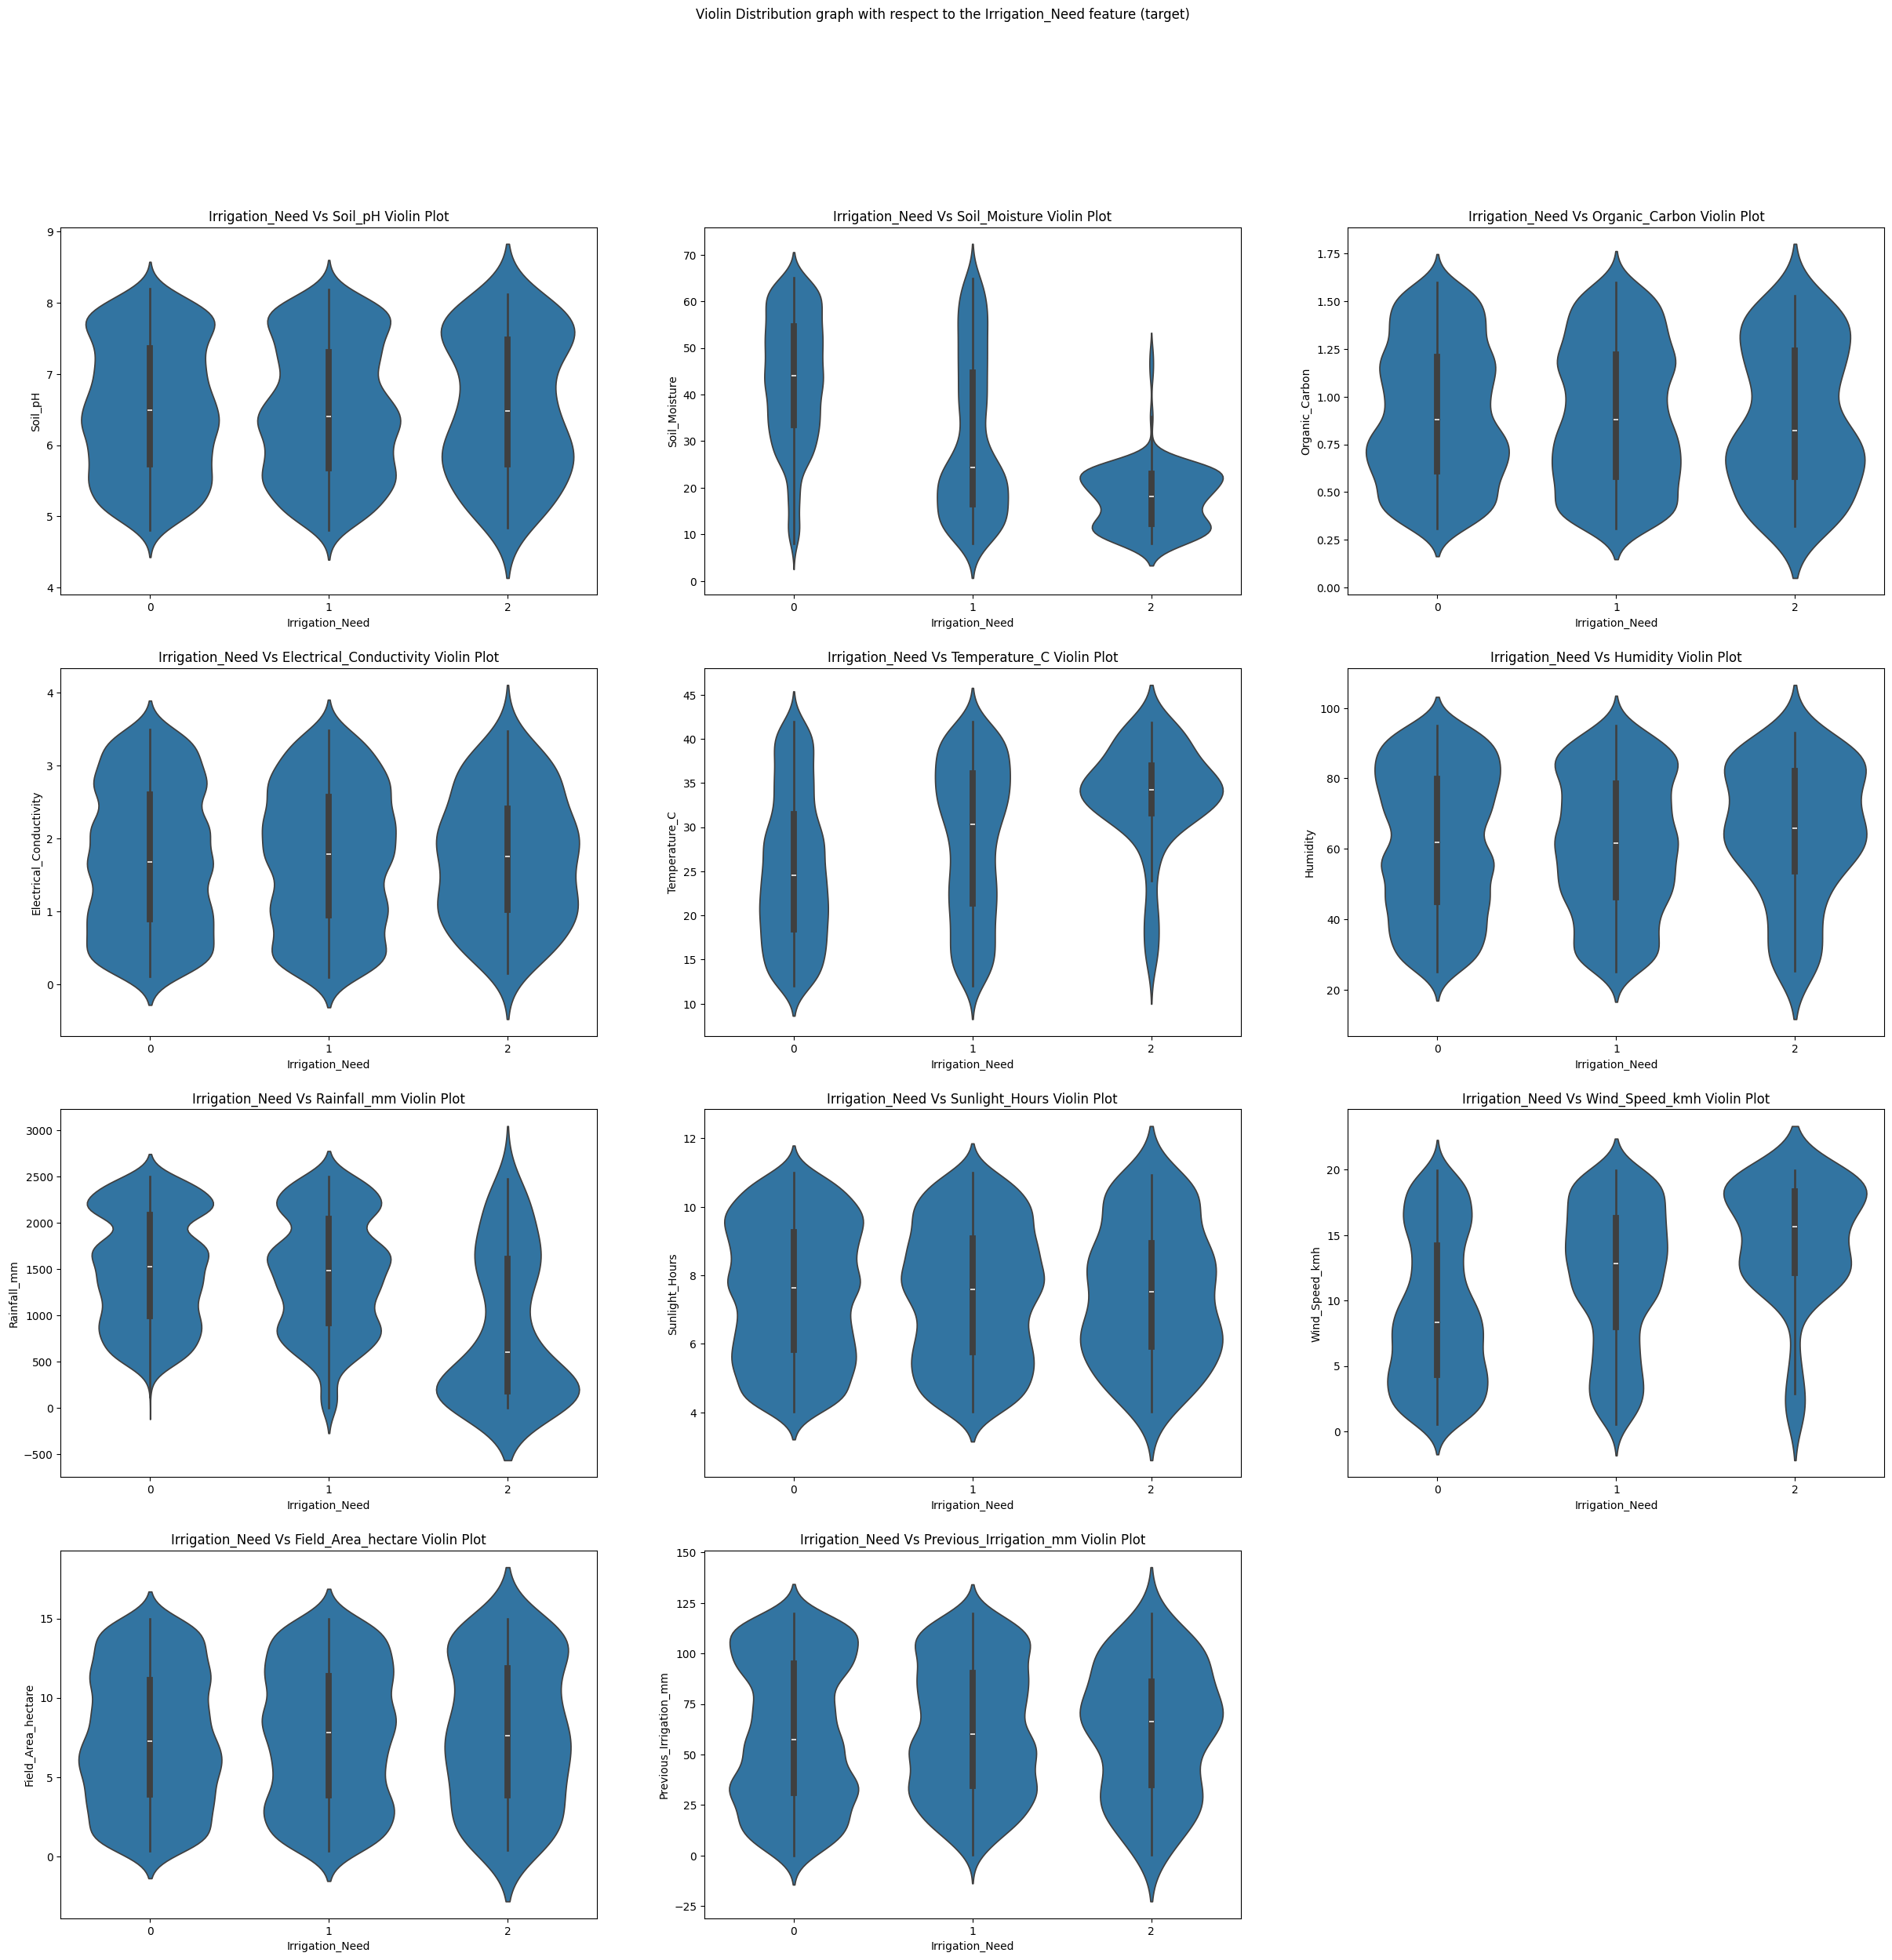

<Figure size 700x700 with 0 Axes>

In [15]:
cols = train_df.select_dtypes(include='number').columns.tolist()
cols.remove('id')
cols.remove('Irrigation_Need')

size = len(cols)
columns = 3
rows = (size + columns - 1) // columns

fig, ax = plt.subplots(rows, columns, figsize=(30, rows*7))
ax = ax.flatten()



plt.figure(figsize=(7,7))
for i, col in enumerate(cols):
    sns.violinplot(sample_df, x='Irrigation_Need', y=col, legend='auto', ax=ax[i])
    ax[i].set_xlabel('Irrigation_Need')
    ax[i].set_ylabel(col)
    ax[i].set_title(f'Irrigation_Need Vs {col} Violin Plot')


# removing extra empty plots
for j in range(i+1, len(ax)):
    fig.delaxes(ax[j])

fig.suptitle('Violin Distribution graph with respect to the Irrigation_Need feature (target)')
plt.tight_layout()
plt.show()

In [16]:
s

NameError: name 's' is not defined

### Filtering Numerical and Categorcial Columns for Scaling and Categorical Columns

In [ ]:
train_df = train_df.drop('id', axis=1)
test_df = test_df.drop('id', axis=1)

In [ ]:
print('All columns:\n{train_df.columns}')

# Selecting columns for train_df
train_num_cols = train_df.select_dtypes(include='number').columns.to_list()
train_num_cols.remove('Irrigation_Need')
print(f'\nNumerical Columns:\n{train_num_cols}')

train_cat_cols = train_df.select_dtypes(include='object').columns.to_list()
print(f'\nCategorical Columns:\n{train_cat_cols}')

# Selecting columns for test_df
test_num_cols = test_df.select_dtypes(include='number').columns.to_list()
print(f'\nNumerical Columns:\n{test_num_cols}')

test_cat_cols = test_df.select_dtypes(include='object').columns.to_list()
print(f'\nCategorical Columns:\n{test_cat_cols}')

## Scaling Dataset

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler().fit(train_df[train_num_cols])

In [ ]:
train_df[train_num_cols] = scaler.transform(train_df[train_num_cols])
test_df[test_num_cols] = scaler.transform(test_df[test_num_cols])

In [ ]:
train_df.head()

In [ ]:
test_df.head()

## Imputing the Categorical Columns

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore').fit(train_df[train_cat_cols])

In [ ]:
encoded_cols = encoder.get_feature_names_out().tolist()
encoded_cols, type(encoded_cols)

In [ ]:
train_df[encoded_cols] = encoder.transform(train_df[train_cat_cols])
test_df[encoded_cols] = encoder.transform(test_df[test_cat_cols])

In [ ]:
train_df.columns, test_df.columns

### Final training and test datasets

In [ ]:
input_cols = train_num_cols + train_cat_cols
target_col = 'Irrigation_Need'

In [ ]:
input_df = train_df[train_num_cols + train_cat_cols]
test_df = test_df[test_num_cols + test_cat_cols]

In [ ]:
train_df.columns, test_df.columns

## Train/Val Split and Test Input and Target

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_val , Y_train, Y_val = train_test_split(input_df[input_cols],
                                                   train_df[target_col],
                                                   test_size=0.2,
                                                   random_state=231)

## Training Models

In [ ]:
from sklearn.metrics import r2_score, root_mean_squared_error, accuracy_score

### LightGBM Model

In [ ]:
import lightgbm

In [ ]:
lgbm = lightgbm.LGBMClassifier()

In [ ]:
lgbm.fit(X_train, Y_train,
         )